In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
IMAGE_DIR = Path("images")

plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["axes.titlesize"] = 9
plt.rcParams["axes.labelsize"] = 8

In [2]:
OBJECT_IMAGES = [
    "apple.jpg", "orange.jpg", "fruits.jpg", "butterfly.jpg", "HappyFish.jpg",
    "cards.png", "chicky_512.png", "smarties.png", "basketball1.png", "box.png",
]

EDGE_IMAGES = [
    "building.jpg", "chessboard.png", "board.jpg", "graf1.png", "graf3.png",
    "home.jpg", "imageTextR.png", "notes.png", "digits.png", "box_in_scene.png",
]

IMAGE_RECORDS = []
for filename in OBJECT_IMAGES:
    IMAGE_RECORDS.append({
        "filename": filename,
        "group": "clear objects/shapes",
        "local_path": str(IMAGE_DIR / filename),
        "dataset_note": "Local image file included with this project",
    })

for filename in EDGE_IMAGES:
    IMAGE_RECORDS.append({
        "filename": filename,
        "group": "distinct edges/boundaries",
        "local_path": str(IMAGE_DIR / filename),
        "dataset_note": "Local image file included with this project",
    })

metadata_df = pd.DataFrame(IMAGE_RECORDS)
display(metadata_df)
print(f"Total images: {len(metadata_df)}")

,filename,group,local_path,dataset_note
0,apple.jpg,clear objects/shapes,images\apple.jpg,Local image file included with this project
1,orange.jpg,clear objects/shapes,images\orange.jpg,Local image file included with this project
2,fruits.jpg,clear objects/shapes,images\fruits.jpg,Local image file included with this project
3,butterfly.jpg,clear objects/shapes,images\butterfly.jpg,Local image file included with this project
4,HappyFish.jpg,clear objects/shapes,images\HappyFish.jpg,Local image file included with this project
5,cards.png,clear objects/shapes,images\cards.png,Local image file included with this project
6,chicky_512.png,clear objects/shapes,images\chicky_512.png,Local image file included with this project
7,smarties.png,clear objects/shapes,images\smarties.png,Local image file included with this project
8,basketball1.png,clear objects/shapes,images\basketball1.png,Local image file included with this project
9,box.png,clear objects/shapes,images\box.png,Local image file included with this project


Total images: 20


In [3]:
def validate_local_images(records):
    local_paths = []
    missing = []
    for record in records:
        local_path = Path(record["local_path"])
        if local_path.exists() and local_path.stat().st_size > 0:
            local_paths.append(local_path)
        else:
            missing.append(str(local_path))
    if missing:
        raise FileNotFoundError("Missing local image files: " + ", ".join(missing))
    return local_paths


def load_image_rgb(path):
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise ValueError(f"Could not load image: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def resize_for_processing(image_rgb, max_dim=128, interpolation=cv2.INTER_AREA):
    height, width = image_rgb.shape[:2]
    scale = min(max_dim / max(height, width), 1.0)
    if scale == 1.0:
        return image_rgb.copy()
    new_width = max(1, int(round(width * scale)))
    new_height = max(1, int(round(height * scale)))
    return cv2.resize(image_rgb, (new_width, new_height), interpolation=interpolation)


def normalize_to_uint8(array):
    array = np.asarray(array, dtype=np.float32)
    min_value = float(array.min())
    max_value = float(array.max())
    if max_value - min_value < 1e-8:
        return np.zeros_like(array, dtype=np.uint8)
    normalized = (array - min_value) / (max_value - min_value)
    return np.clip(normalized * 255, 0, 255).astype(np.uint8)


def plot_image_grid(images, titles, cols=5, cmap=None, suptitle=None, figsize_per_image=(3.0, 2.4)):
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per_image[0], rows * figsize_per_image[1]))
    axes = np.array(axes).reshape(rows, cols)
    for axis in axes.ravel():
        axis.axis("off")
    for axis, image, title in zip(axes.ravel(), images, titles):
        axis.imshow(image, cmap=cmap)
        axis.set_title(title)
        axis.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=14)
    fig.tight_layout()
    plt.show()


def build_color_spatial_features(image_rgb, spatial_weight=0.35):
    height, width = image_rgb.shape[:2]
    color_features = image_rgb.reshape(-1, 3).astype(np.float32) / 255.0
    yy, xx = np.mgrid[0:height, 0:width]
    spatial_features = np.column_stack([
        xx.reshape(-1) / max(width - 1, 1),
        yy.reshape(-1) / max(height - 1, 1),
    ]).astype(np.float32)
    return np.column_stack([color_features, spatial_features * spatial_weight])


def recolor_by_cluster(image_rgb, labels):
    pixels = image_rgb.reshape(-1, 3).astype(np.float32)
    labels = labels.reshape(-1)
    segmented = np.zeros_like(pixels)
    for label in np.unique(labels):
        mask = labels == label
        segmented[mask] = pixels[mask].mean(axis=0)
    return np.clip(segmented.reshape(image_rgb.shape), 0, 255).astype(np.uint8)


def cluster_boundaries(label_map):
    boundaries = np.zeros(label_map.shape, dtype=bool)
    boundaries[:-1, :] |= label_map[:-1, :] != label_map[1:, :]
    boundaries[:, :-1] |= label_map[:, :-1] != label_map[:, 1:]
    return boundaries


def overlay_boundaries(image_rgb, boundaries, color=(255, 0, 0)):
    overlay = image_rgb.copy()
    overlay[boundaries] = np.array(color, dtype=np.uint8)
    return overlay


def segmentation_metrics(features, labels, max_samples=1500, random_state=RANDOM_STATE):
    labels = np.asarray(labels)
    features = np.asarray(features)
    cluster_count = len(np.unique(labels))
    if cluster_count < 2 or cluster_count >= len(labels):
        return {"silhouette_score": np.nan, "davies_bouldin_score": np.nan}
    rng = np.random.default_rng(random_state)
    if len(labels) > max_samples:
        sample_idx = rng.choice(len(labels), size=max_samples, replace=False)
        sampled_features = features[sample_idx]
        sampled_labels = labels[sample_idx]
    else:
        sampled_features = features
        sampled_labels = labels
    if len(np.unique(sampled_labels)) < 2:
        return {"silhouette_score": np.nan, "davies_bouldin_score": np.nan}
    return {
        "silhouette_score": float(silhouette_score(sampled_features, sampled_labels)),
        "davies_bouldin_score": float(davies_bouldin_score(sampled_features, sampled_labels)),
    }


def kmeans_segment(image_rgb, k, max_dim=128):
    small = resize_for_processing(image_rgb, max_dim=max_dim)
    features = small.reshape(-1, 3).astype(np.float32) / 255.0
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(features)
    centers = np.clip(model.cluster_centers_ * 255, 0, 255).astype(np.uint8)
    segmented = centers[labels].reshape(small.shape)
    metrics = segmentation_metrics(features, labels)
    return {
        "image": small,
        "segmented": segmented,
        "labels": labels.reshape(small.shape[:2]),
        "features": features,
        "cluster_count": k,
        "metrics": metrics,
    }


def sklearn_tree_to_linkage(model):
    children = model.children_
    distances = model.distances_
    n_samples = len(model.labels_)
    counts = np.zeros(children.shape[0])
    for i, merge in enumerate(children):
        count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                count += 1
            else:
                count += counts[child_idx - n_samples]
        counts[i] = count
    return np.column_stack([children, distances, counts]).astype(float)


def agglomerative_segment(image_rgb, max_dim=52, target_clusters=6):
    small = resize_for_processing(image_rgb, max_dim=max_dim)
    features = build_color_spatial_features(small, spatial_weight=0.35)
    model = AgglomerativeClustering(n_clusters=None, distance_threshold=0, linkage="ward", compute_distances=True)
    model.fit(features)
    linkage_matrix = sklearn_tree_to_linkage(model)
    distances = np.sort(model.distances_)
    n_samples = features.shape[0]
    candidates = []
    for desired_clusters in range(2, 13):
        merge_index = n_samples - desired_clusters - 1
        if 0 <= merge_index < len(distances):
            threshold = float(distances[merge_index] + 1e-8)
            labels = fcluster(linkage_matrix, t=threshold, criterion="distance") - 1
            cluster_count = len(np.unique(labels))
            if 2 <= cluster_count <= 12:
                candidates.append((abs(cluster_count - target_clusters), cluster_count, threshold, labels))
    if candidates:
        _, cluster_count, threshold, labels = sorted(candidates, key=lambda item: (item[0], item[1]))[0]
    else:
        fallback = AgglomerativeClustering(n_clusters=target_clusters, linkage="ward")
        labels = fallback.fit_predict(features)
        cluster_count = len(np.unique(labels))
        threshold = float("nan")
    label_map = labels.reshape(small.shape[:2])
    segmented = recolor_by_cluster(small, label_map)
    boundaries = cluster_boundaries(label_map)
    overlay = overlay_boundaries(segmented, boundaries)
    metrics = segmentation_metrics(features, labels)
    return {
        "image": small,
        "segmented": segmented,
        "labels": label_map,
        "features": features,
        "cluster_count": int(cluster_count),
        "threshold": threshold,
        "boundaries": boundaries,
        "overlay": overlay,
        "metrics": metrics,
    }

In [4]:
def threshold_edge_map(magnitude, percentile=85):
    magnitude = np.asarray(magnitude, dtype=np.float32)
    positive = magnitude[magnitude > 0]
    threshold = float(np.percentile(positive, percentile)) if positive.size else 0.0
    return (magnitude >= threshold).astype(np.uint8) * 255, threshold


def to_gray_float(image_rgb):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    return gray.astype(np.float32)


def sobel_edges(image_rgb, max_dim=220):
    small = resize_for_processing(image_rgb, max_dim=max_dim)
    gray = to_gray_float(small)
    kernel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    kernel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
    gx = cv2.filter2D(gray, cv2.CV_32F, kernel_x)
    gy = cv2.filter2D(gray, cv2.CV_32F, kernel_y)
    magnitude = np.hypot(gx, gy)
    direction = np.arctan2(gy, gx)
    edge_map, threshold = threshold_edge_map(magnitude, percentile=85)
    return {"image": small, "gx": gx, "gy": gy, "magnitude": magnitude, "magnitude_uint8": normalize_to_uint8(magnitude), "direction": direction, "edge_map": edge_map, "threshold": threshold}


def prewitt_edges(image_rgb, max_dim=220):
    small = resize_for_processing(image_rgb, max_dim=max_dim)
    gray = to_gray_float(small)
    kernel_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
    kernel_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)
    gx = cv2.filter2D(gray, cv2.CV_32F, kernel_x)
    gy = cv2.filter2D(gray, cv2.CV_32F, kernel_y)
    magnitude = np.hypot(gx, gy)
    direction = np.arctan2(gy, gx)
    edge_map, threshold = threshold_edge_map(magnitude, percentile=85)
    return {"image": small, "gx": gx, "gy": gy, "magnitude": magnitude, "magnitude_uint8": normalize_to_uint8(magnitude), "direction": direction, "edge_map": edge_map, "threshold": threshold}


def non_maximum_suppression(magnitude, direction):
    height, width = magnitude.shape
    suppressed = np.zeros((height, width), dtype=np.float32)
    angle = (np.rad2deg(direction) + 180) % 180
    for y in range(1, height - 1):
        for x in range(1, width - 1):
            q = 0.0
            r = 0.0
            current_angle = angle[y, x]
            if (0 <= current_angle < 22.5) or (157.5 <= current_angle <= 180):
                q = magnitude[y, x + 1]
                r = magnitude[y, x - 1]
            elif 22.5 <= current_angle < 67.5:
                q = magnitude[y + 1, x - 1]
                r = magnitude[y - 1, x + 1]
            elif 67.5 <= current_angle < 112.5:
                q = magnitude[y + 1, x]
                r = magnitude[y - 1, x]
            elif 112.5 <= current_angle < 157.5:
                q = magnitude[y - 1, x - 1]
                r = magnitude[y + 1, x + 1]
            if magnitude[y, x] >= q and magnitude[y, x] >= r:
                suppressed[y, x] = magnitude[y, x]
    return suppressed


def hysteresis_threshold(nms, low_threshold, high_threshold):
    strong = nms >= high_threshold
    weak = (nms >= low_threshold) & ~strong
    candidates = strong | weak
    num_labels, labels = cv2.connectedComponents(candidates.astype(np.uint8), connectivity=8)
    output = np.zeros_like(candidates, dtype=np.uint8)
    for label in range(1, num_labels):
        component = labels == label
        if np.any(strong & component):
            output[component] = 255
    return output


def manual_canny_edges(image_rgb, max_dim=220, low_ratio=0.4, high_percentile=86):
    small = resize_for_processing(image_rgb, max_dim=max_dim)
    gray = to_gray_float(small)
    blurred = cv2.GaussianBlur(gray, (5, 5), sigmaX=1.2)
    kernel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    kernel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
    gx = cv2.filter2D(blurred, cv2.CV_32F, kernel_x)
    gy = cv2.filter2D(blurred, cv2.CV_32F, kernel_y)
    magnitude = np.hypot(gx, gy)
    direction = np.arctan2(gy, gx)
    nms = non_maximum_suppression(magnitude, direction)
    positive = nms[nms > 0]
    high_threshold = float(np.percentile(positive, high_percentile)) if positive.size else 0.0
    low_threshold = low_ratio * high_threshold
    edge_map = hysteresis_threshold(nms, low_threshold, high_threshold)
    return {"image": small, "blurred": blurred, "magnitude": magnitude, "magnitude_uint8": normalize_to_uint8(magnitude), "direction": direction, "nms": nms, "nms_uint8": normalize_to_uint8(nms), "edge_map": edge_map, "low_threshold": low_threshold, "high_threshold": high_threshold}


def edge_metrics(edge_result):
    edge_map = edge_result["edge_map"]
    magnitude = edge_result["magnitude"]
    edge_mask = edge_map > 0
    edge_density = float(edge_mask.mean())
    mean_strength = float(magnitude[edge_mask].mean()) if np.any(edge_mask) else 0.0
    return {"edge_density": edge_density, "mean_edge_strength": mean_strength}

Local images available: 20


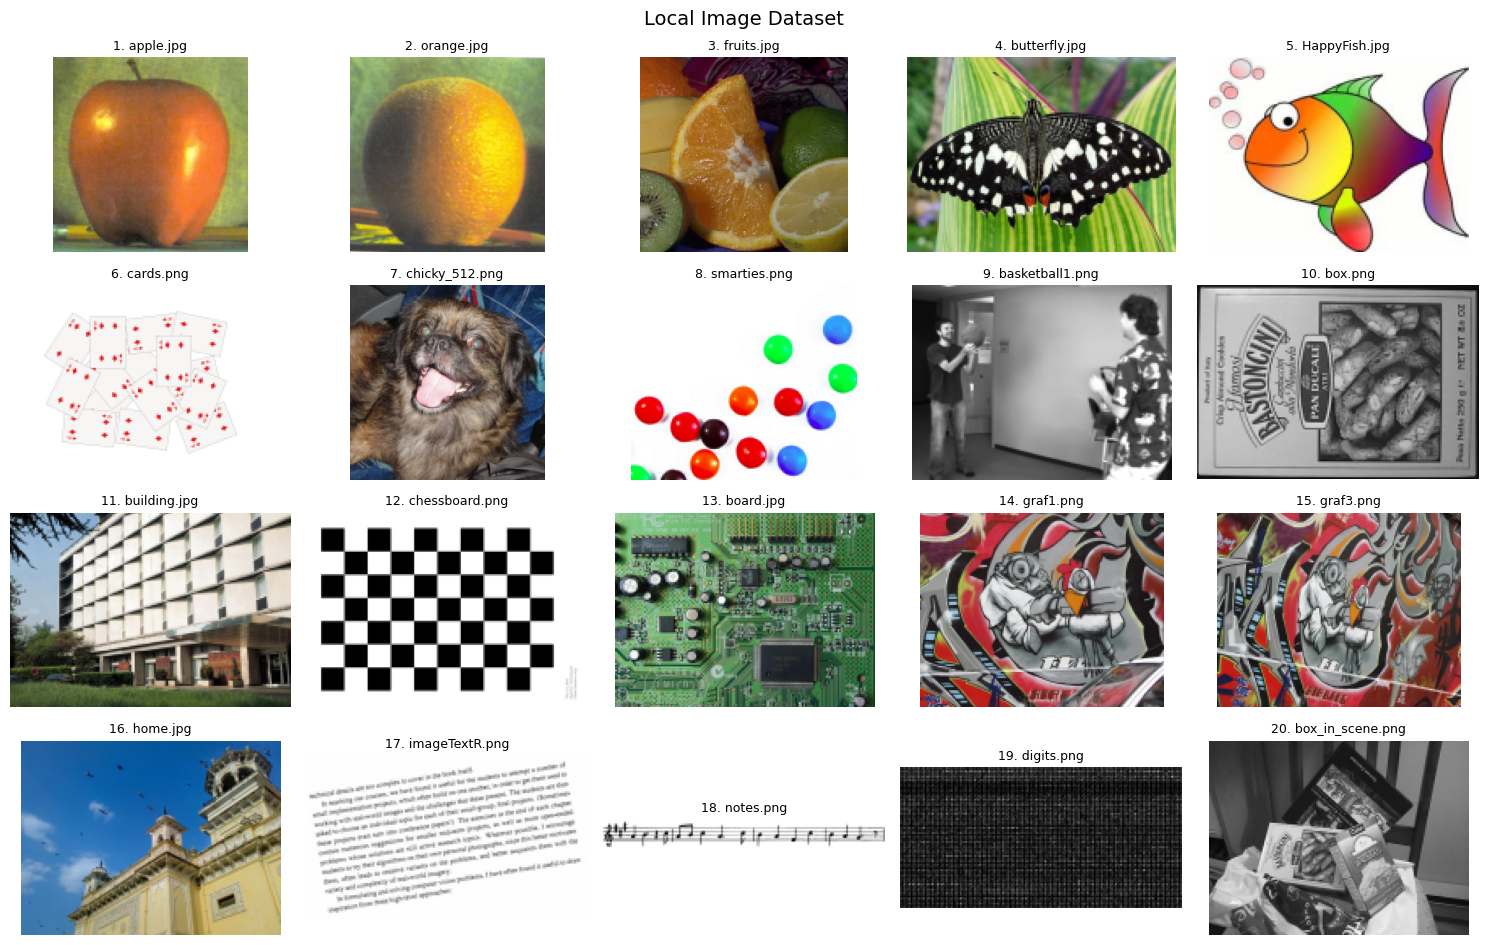

In [5]:
local_paths = validate_local_images(IMAGE_RECORDS)
print(f"Local images available: {len(local_paths)}")

images = {}
for record in IMAGE_RECORDS:
    images[record["filename"]] = load_image_rgb(record["local_path"])

assert len(images) == 20, "The assignment requires exactly 20 images."

preview_images = [resize_for_processing(images[record["filename"]], max_dim=160) for record in IMAGE_RECORDS]
preview_titles = [f"{i+1}. {record['filename']}" for i, record in enumerate(IMAGE_RECORDS)]
plot_image_grid(preview_images, preview_titles, cols=5, suptitle="Local Image Dataset")

In [6]:
k_values = [2, 3, 4, 5]
kmeans_results = {}
segmentation_rows = []

for record in IMAGE_RECORDS:
    filename = record["filename"]
    image = images[filename]
    kmeans_results[filename] = {}
    for k in k_values:
        result = kmeans_segment(image, k=k, max_dim=128)
        kmeans_results[filename][k] = result
        segmentation_rows.append({
            "method": "K-Means",
            "image": filename,
            "parameter": f"k={k}",
            "cluster_count": result["cluster_count"],
            "silhouette_score": result["metrics"]["silhouette_score"],
            "davies_bouldin_score": result["metrics"]["davies_bouldin_score"],
        })

print(f"K-Means outputs created: {sum(len(v) for v in kmeans_results.values())}")

K-Means outputs created: 80


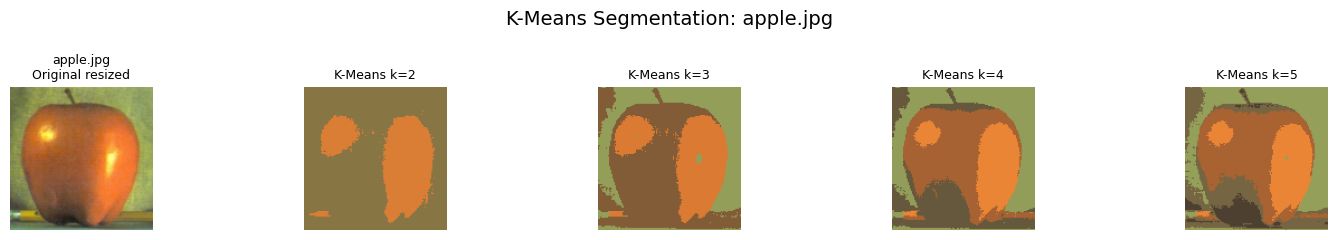

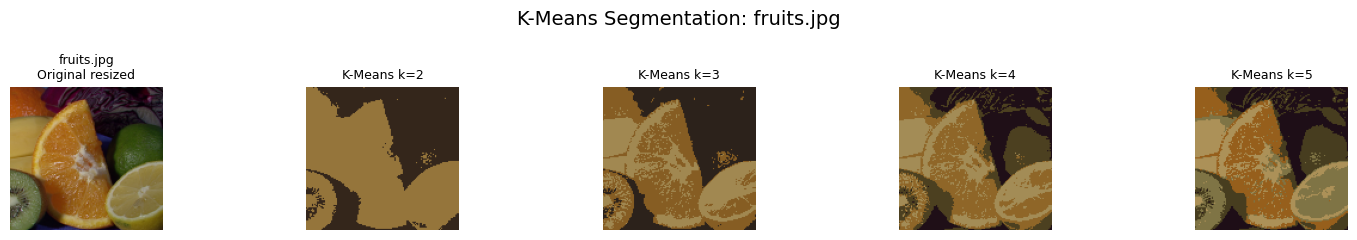

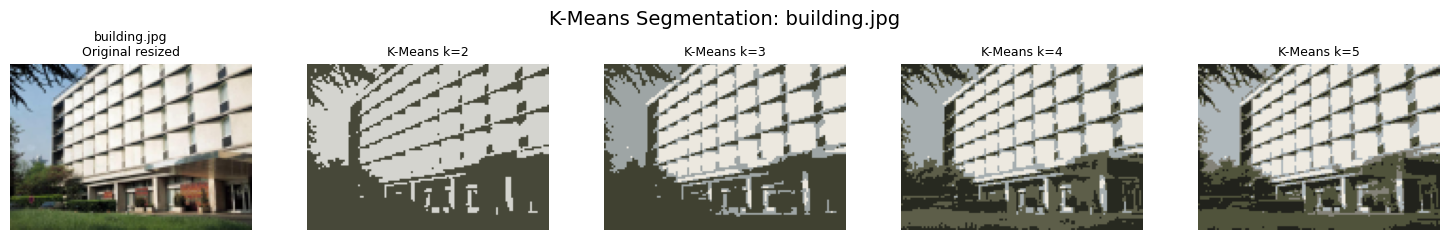

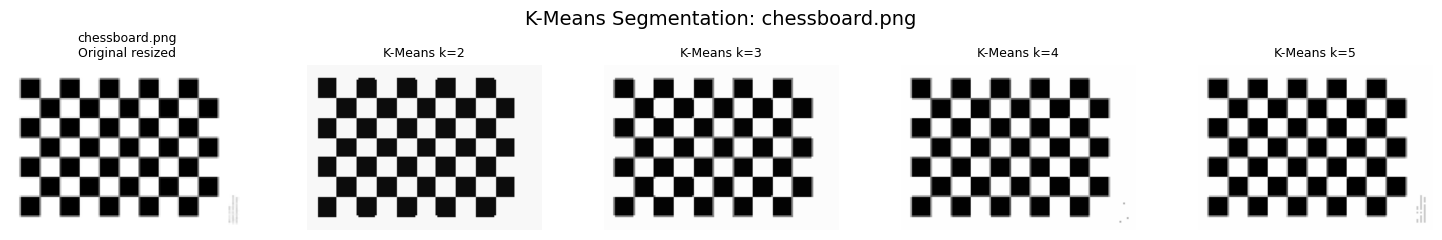

In [7]:
representative_images = ["apple.jpg", "fruits.jpg", "building.jpg", "chessboard.png"]

for filename in representative_images:
    gallery = [kmeans_results[filename][2]["image"]]
    gallery_titles = [f"{filename}\nOriginal resized"]
    for k in k_values:
        gallery.append(kmeans_results[filename][k]["segmented"])
        gallery_titles.append(f"K-Means k={k}")
    plot_image_grid(gallery, gallery_titles, cols=5, suptitle=f"K-Means Segmentation: {filename}")

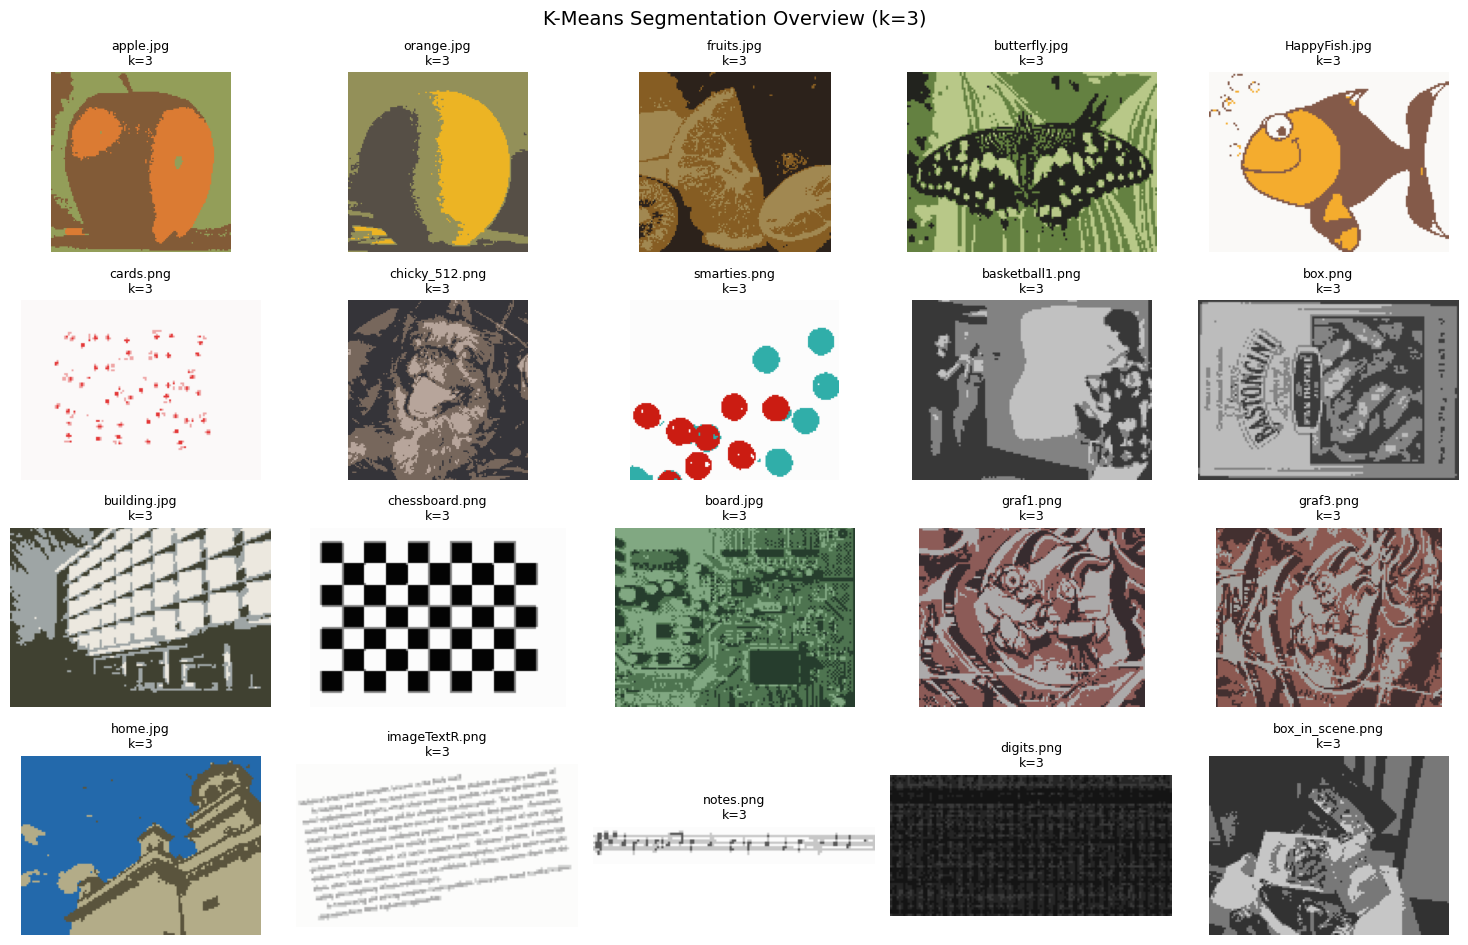

In [8]:
k3_images = [kmeans_results[record["filename"]][3]["segmented"] for record in IMAGE_RECORDS]
k3_titles = [f"{record['filename']}\nk=3" for record in IMAGE_RECORDS]
plot_image_grid(k3_images, k3_titles, cols=5, suptitle="K-Means Segmentation Overview (k=3)")

In [9]:
agglomerative_results = {}

for idx, record in enumerate(IMAGE_RECORDS, start=1):
    filename = record["filename"]
    print(f"[{idx:02d}/20] Agglomerative clustering: {filename}")
    result = agglomerative_segment(images[filename], max_dim=52, target_clusters=6)
    agglomerative_results[filename] = result
    segmentation_rows.append({
        "method": "Agglomerative",
        "image": filename,
        "parameter": f"threshold={result['threshold']:.4f}",
        "cluster_count": result["cluster_count"],
        "silhouette_score": result["metrics"]["silhouette_score"],
        "davies_bouldin_score": result["metrics"]["davies_bouldin_score"],
    })

print(f"Agglomerative outputs created: {len(agglomerative_results)}")

[01/20] Agglomerative clustering: apple.jpg
[02/20] Agglomerative clustering: orange.jpg
[03/20] Agglomerative clustering: fruits.jpg
[04/20] Agglomerative clustering: butterfly.jpg
[05/20] Agglomerative clustering: HappyFish.jpg
[06/20] Agglomerative clustering: cards.png
[07/20] Agglomerative clustering: chicky_512.png
[08/20] Agglomerative clustering: smarties.png
[09/20] Agglomerative clustering: basketball1.png
[10/20] Agglomerative clustering: box.png
[11/20] Agglomerative clustering: building.jpg
[12/20] Agglomerative clustering: chessboard.png
[13/20] Agglomerative clustering: board.jpg
[14/20] Agglomerative clustering: graf1.png
[15/20] Agglomerative clustering: graf3.png
[16/20] Agglomerative clustering: home.jpg
[17/20] Agglomerative clustering: imageTextR.png
[18/20] Agglomerative clustering: notes.png
[19/20] Agglomerative clustering: digits.png
[20/20] Agglomerative clustering: box_in_scene.png
Agglomerative outputs created: 20


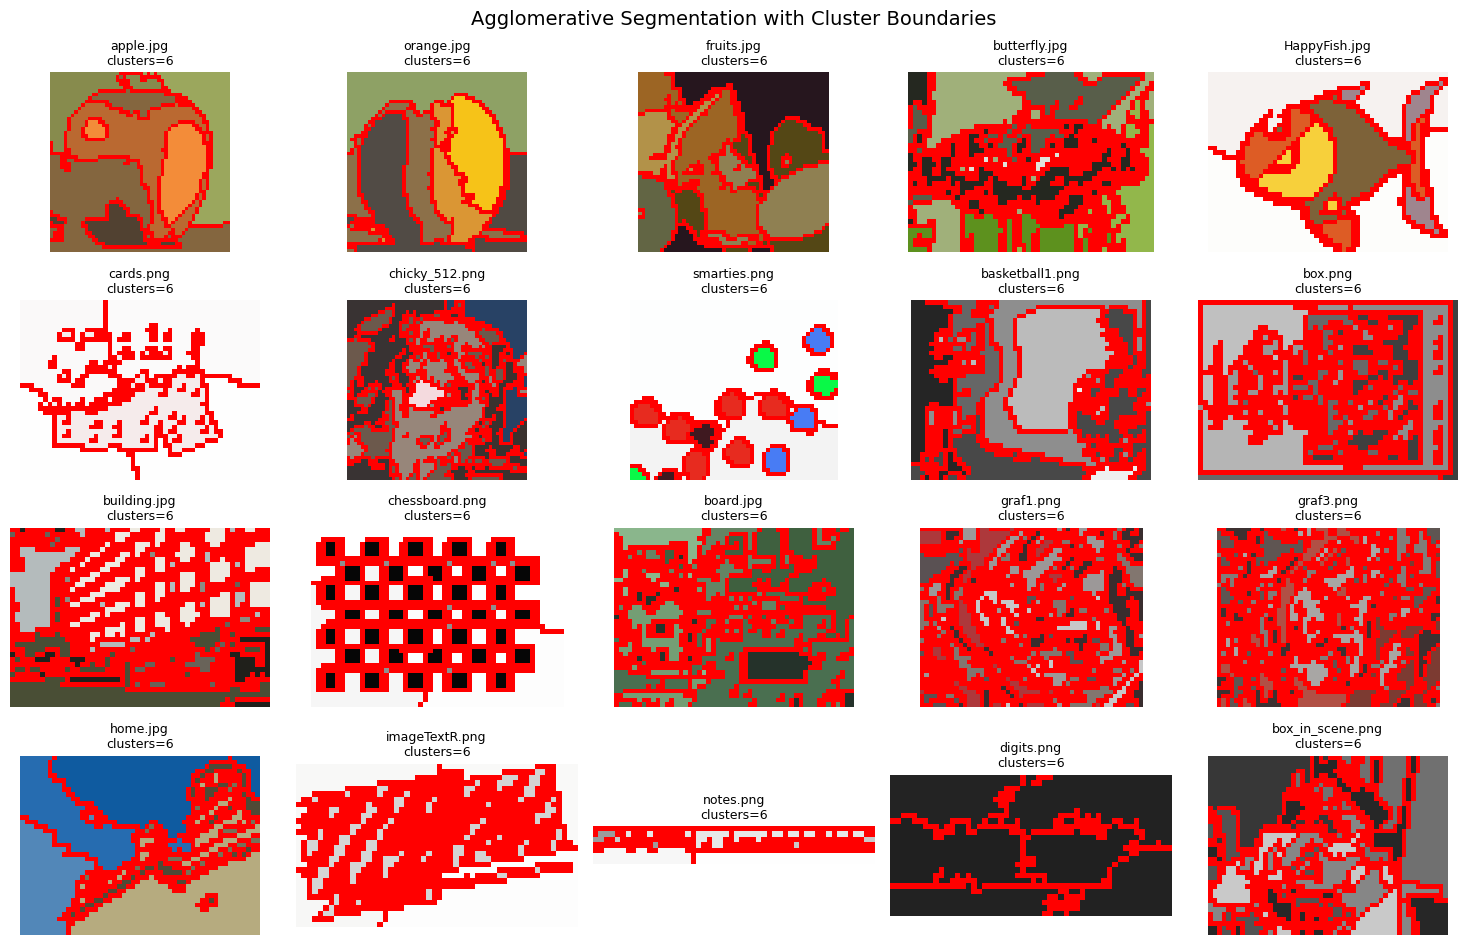

In [12]:
agglo_overlays = [agglomerative_results[record["filename"]]["overlay"]
                  
for record in IMAGE_RECORDS]
agglo_titles = [
    f"{record['filename']}\nclusters={agglomerative_results[record['filename']]['cluster_count']}"
    
    for record in IMAGE_RECORDS
]
plot_image_grid(agglo_overlays, agglo_titles, cols=5, suptitle="Agglomerative Segmentation with Cluster Boundaries")

In [13]:
segmentation_df = pd.DataFrame(segmentation_rows)
segmentation_df = segmentation_df.sort_values(["image", "method", "parameter"]).reset_index(drop=True)
display(segmentation_df)

summary_segmentation = (
    segmentation_df
    .groupby("method")[["silhouette_score", "davies_bouldin_score", "cluster_count"]]
    .mean(numeric_only=True)
    .reset_index()
)
display(summary_segmentation)

,method,image,parameter,cluster_count,silhouette_score,davies_bouldin_score
0,Agglomerative,HappyFish.jpg,threshold=5.1876,6,0.335629,1.220739
1,K-Means,HappyFish.jpg,k=2,2,0.728905,0.468312
2,K-Means,HappyFish.jpg,k=3,3,0.707547,0.775934
3,K-Means,HappyFish.jpg,k=4,4,0.696939,0.952140
4,K-Means,HappyFish.jpg,k=5,5,0.712510,0.854018
...,...,...,...,...,...,...
95,Agglomerative,smarties.png,threshold=4.3699,6,0.394480,0.812051
96,K-Means,smarties.png,k=2,2,0.840289,0.631137
97,K-Means,smarties.png,k=3,3,0.880551,0.699334
98,K-Means,smarties.png,k=4,4,0.898227,0.450003


,method,silhouette_score,davies_bouldin_score,cluster_count
0,Agglomerative,0.306509,1.088371,6.0
1,K-Means,0.612384,0.606844,3.5


In [14]:
edge_results = {}
edge_rows = []

for record in IMAGE_RECORDS:
    filename = record["filename"]
    image = images[filename]
    sobel_result = sobel_edges(image, max_dim=220)
    prewitt_result = prewitt_edges(image, max_dim=220)
    canny_result = manual_canny_edges(image, max_dim=220)
    edge_results[filename] = {"Sobel": sobel_result, "Prewitt": prewitt_result, "Canny": canny_result}
    for method, result in edge_results[filename].items():
        metrics = edge_metrics(result)
        edge_rows.append({
            "method": method,
            "image": filename,
            "edge_density": metrics["edge_density"],
            "mean_edge_strength": metrics["mean_edge_strength"],
        })

print(f"Edge detector result sets created: {len(edge_results) * 3}")

Edge detector result sets created: 60


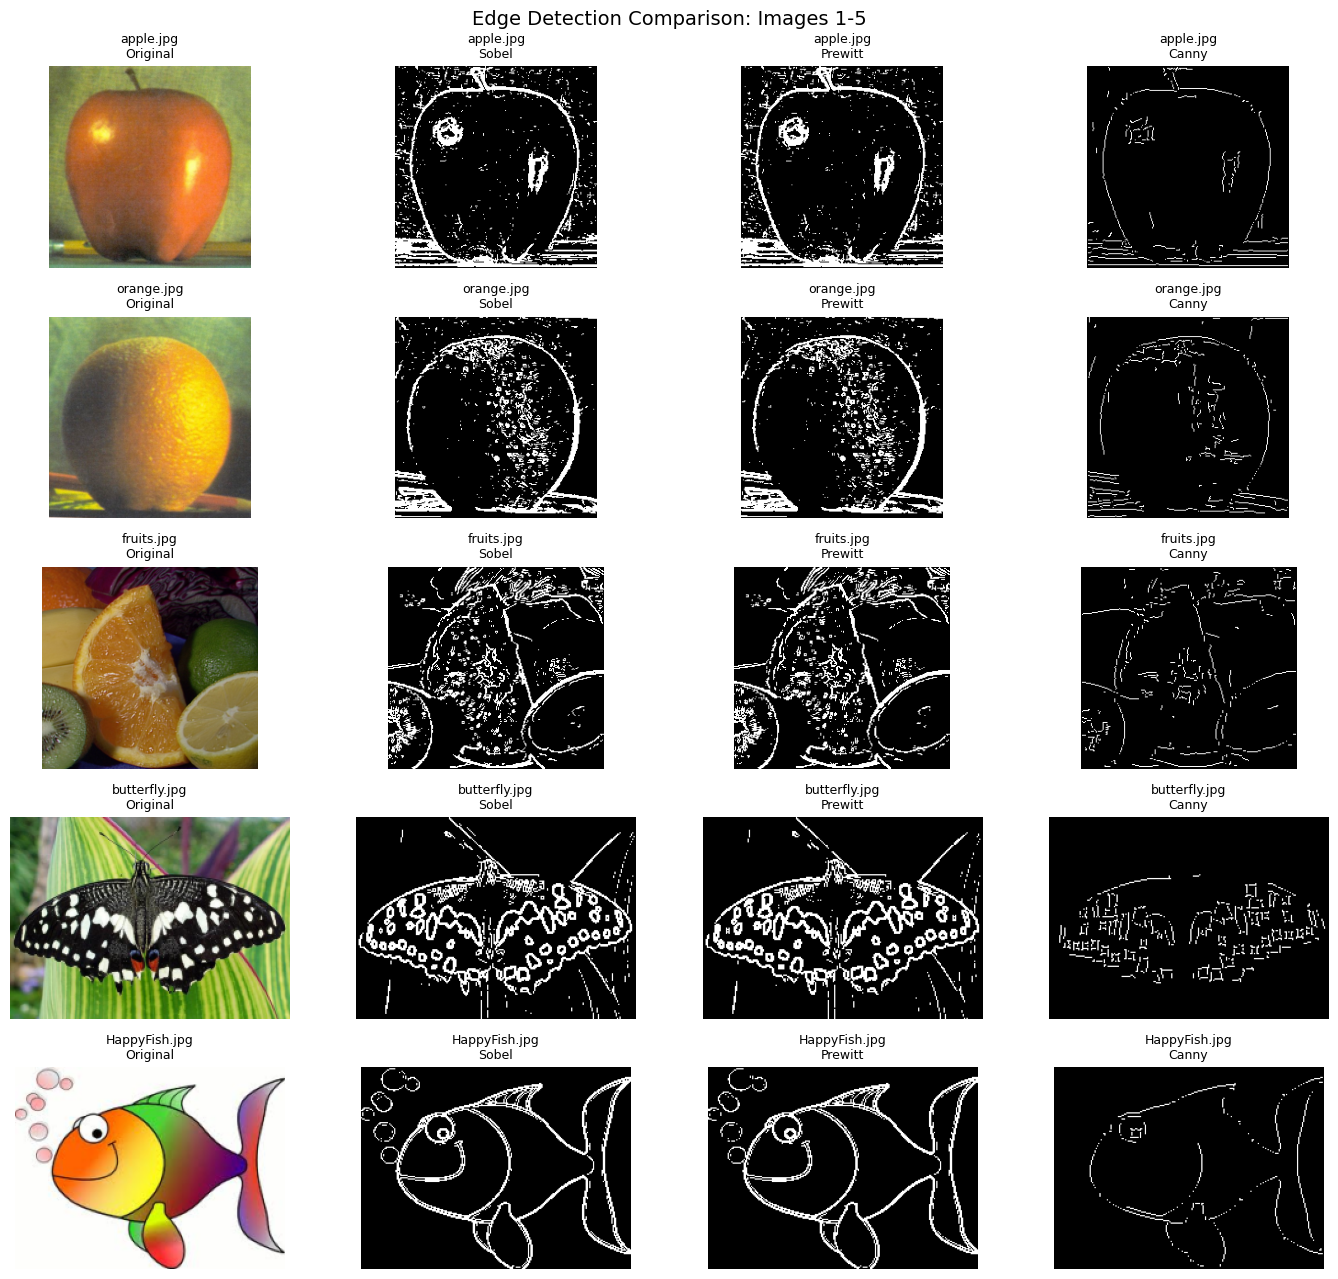

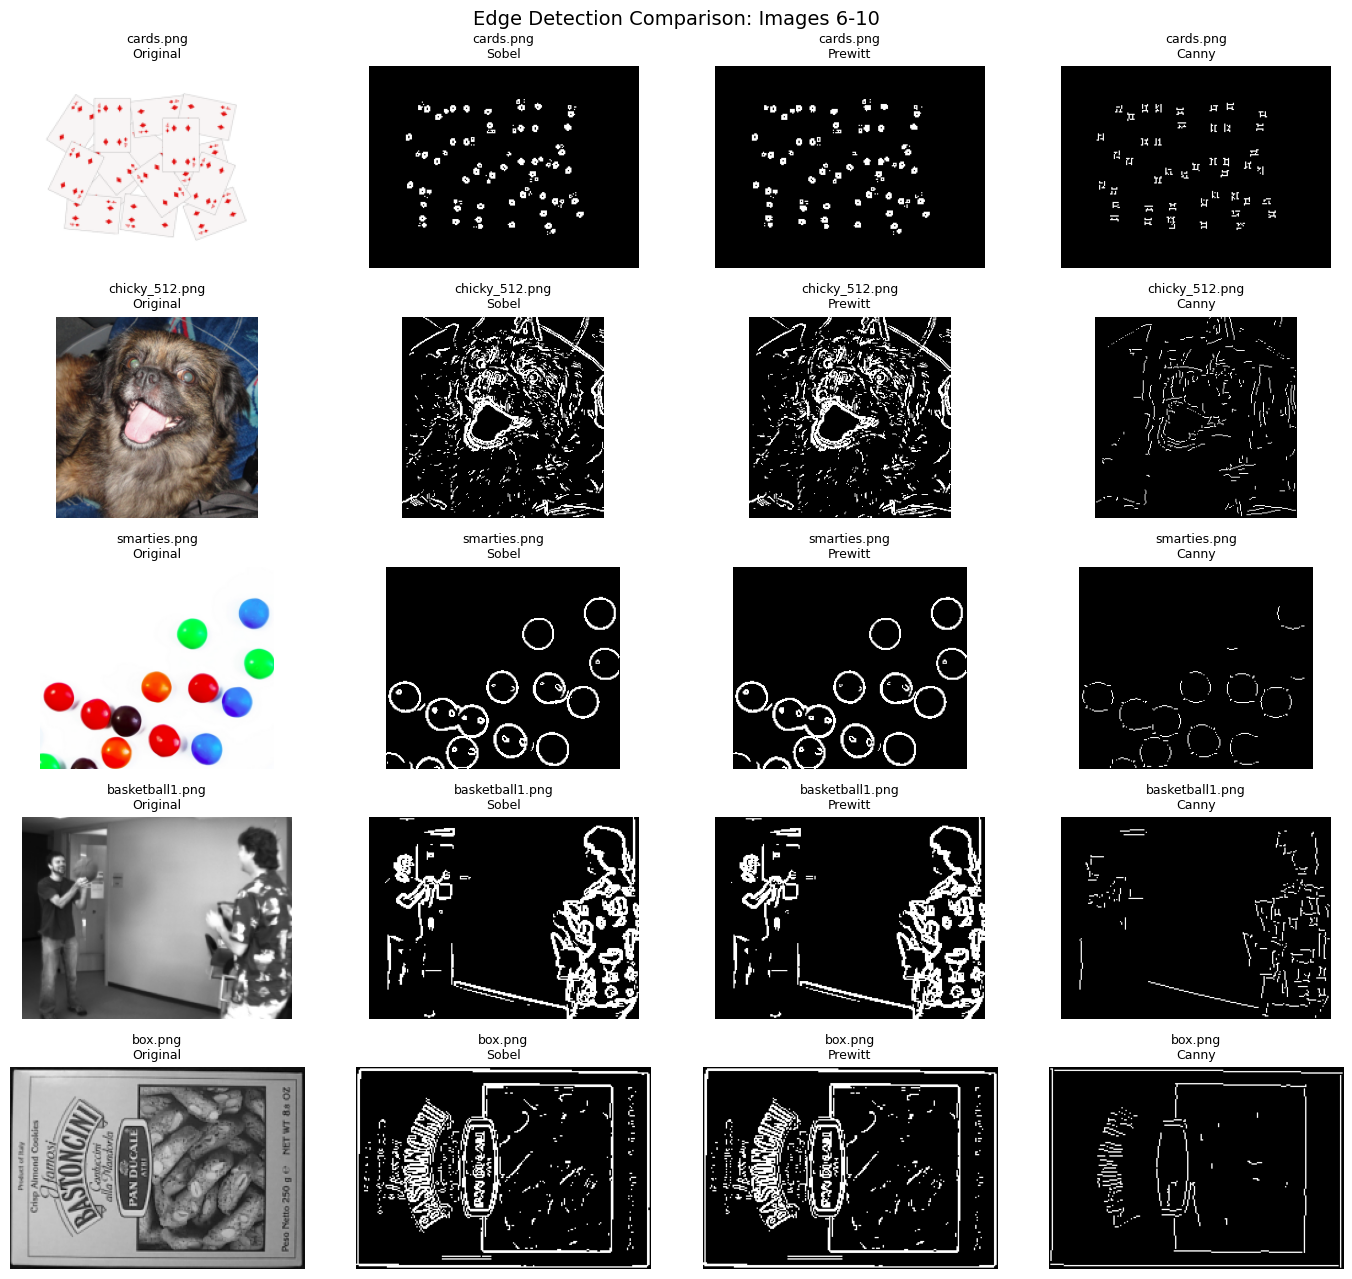

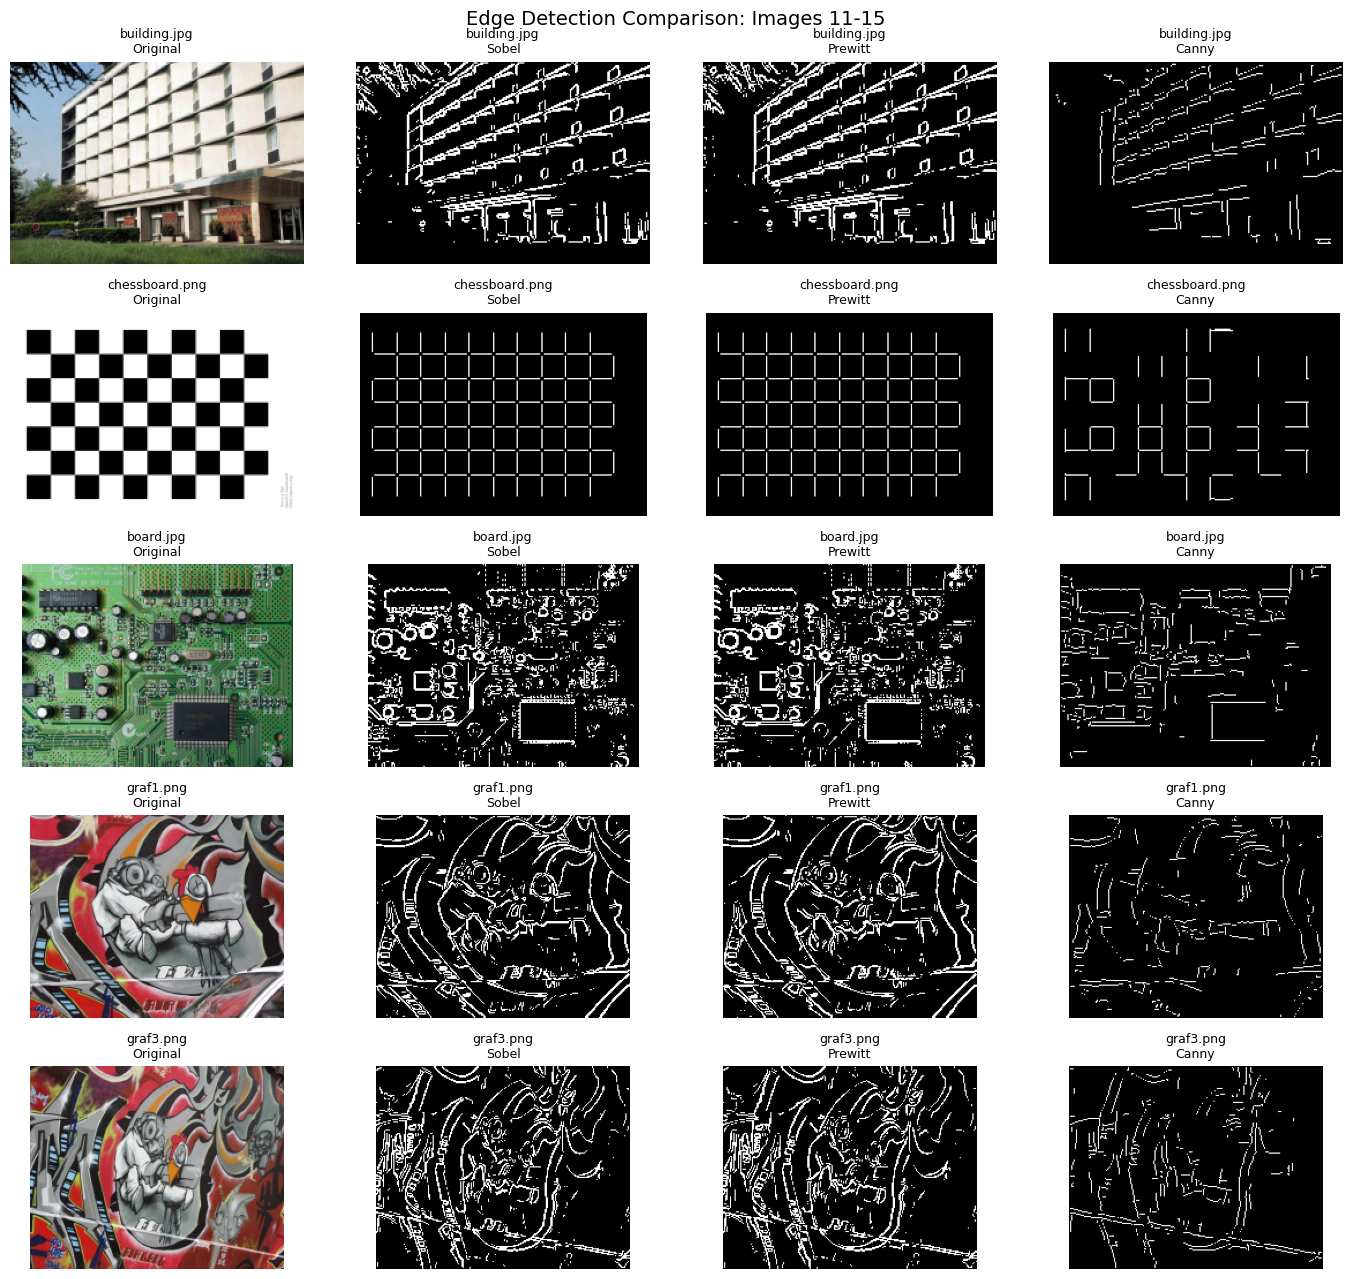

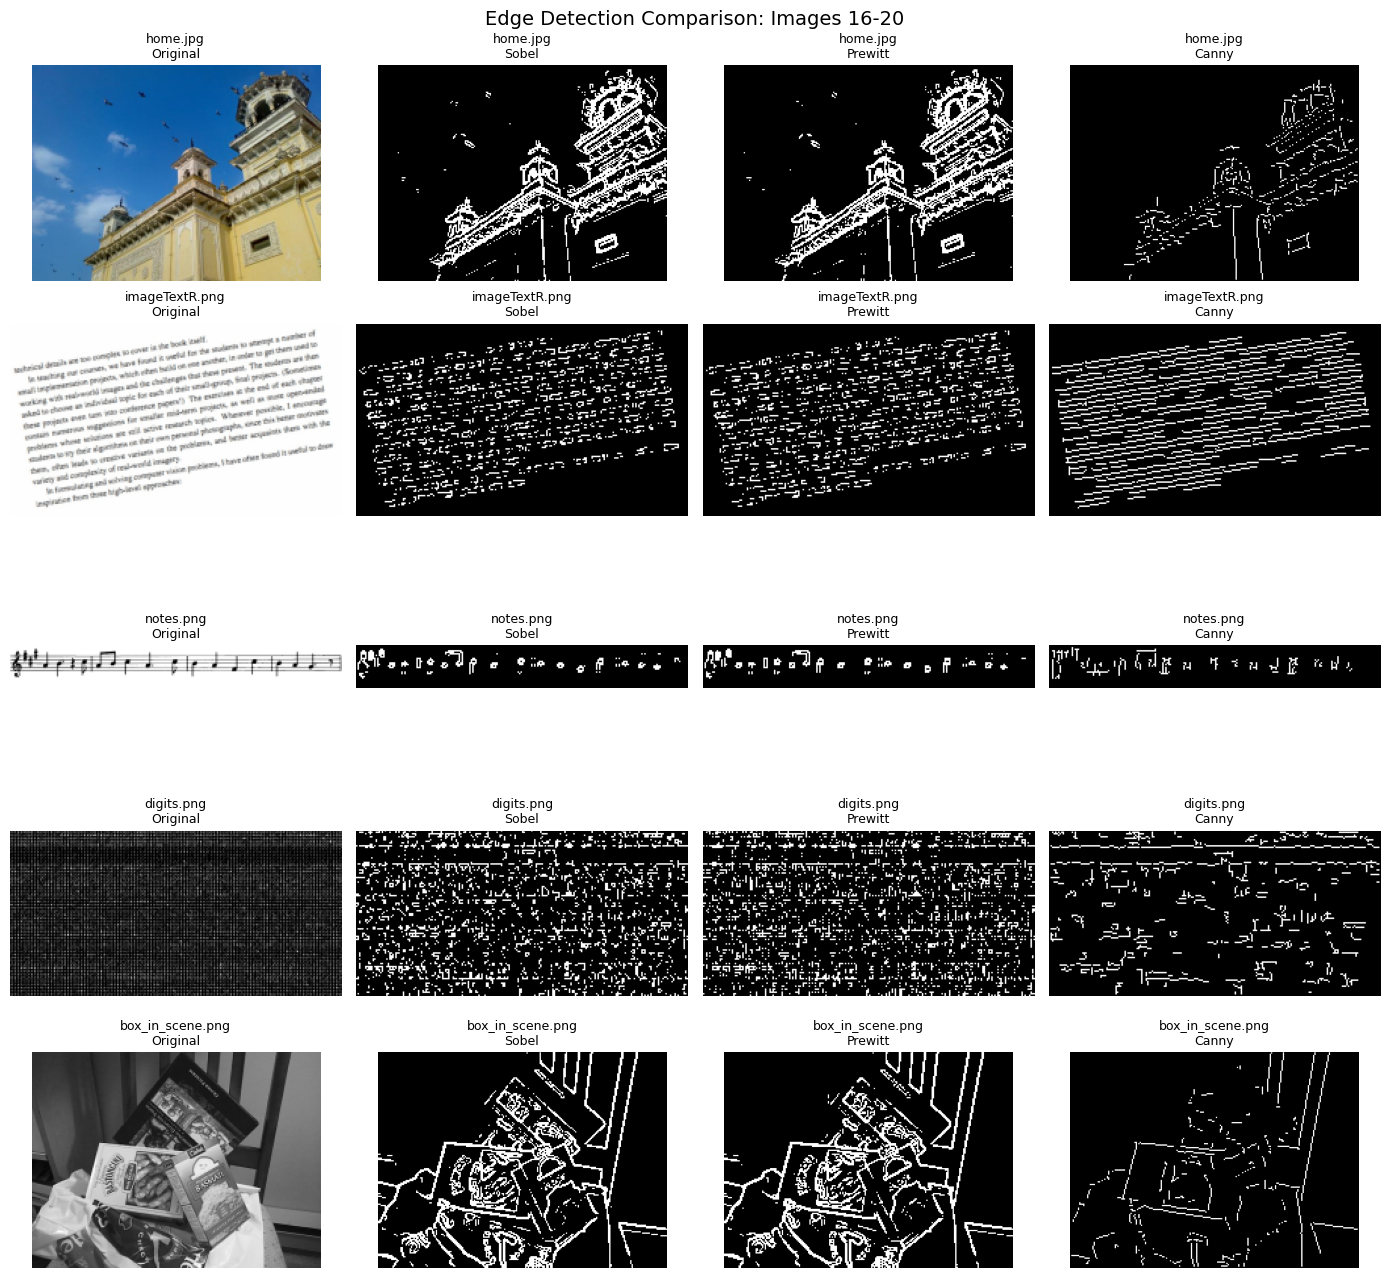

In [15]:
for start in range(0, len(IMAGE_RECORDS), 5):
    batch = IMAGE_RECORDS[start:start + 5]
    fig, axes = plt.subplots(len(batch), 4, figsize=(14, len(batch) * 2.6))
    if len(batch) == 1:
        axes = axes.reshape(1, -1)
    for row, record in enumerate(batch):
        filename = record["filename"]
        original = edge_results[filename]["Sobel"]["image"]
        panels = [
            (original, "Original", None),
            (edge_results[filename]["Sobel"]["edge_map"], "Sobel", "gray"),
            (edge_results[filename]["Prewitt"]["edge_map"], "Prewitt", "gray"),
            (edge_results[filename]["Canny"]["edge_map"], "Canny", "gray"),
        ]
        for col, (panel, title, cmap) in enumerate(panels):
            axes[row, col].imshow(panel, cmap=cmap)
            axes[row, col].set_title(f"{filename}\n{title}")
            axes[row, col].axis("off")
    fig.suptitle(f"Edge Detection Comparison: Images {start + 1}-{start + len(batch)}", fontsize=14)
    fig.tight_layout()
    plt.show()

In [17]:
edge_df = pd.DataFrame(edge_rows)
edge_df = edge_df.sort_values(["image", "method"]).reset_index(drop=True)
display(edge_df)

summary_edges = (
    edge_df
    .groupby("method")[["edge_density", "mean_edge_strength"]]
    .mean(numeric_only=True)
    .reset_index()
)
display(summary_edges)

#comprizon 

print("Segmentation comparison:")
print("- K-Means is fast and produces clean color-based regions, especially when objects differ strongly in color from the background.")
print("- Increasing k adds detail, but very high k can split one object into several color regions.")
print("- Agglomerative clustering uses color plus spatial position, so its regions are more connected and boundary-like, but it is slower.")
print("- Boundary overlays make the Agglomerative segments easier to inspect visually.")
print()
print("Edge detection comparison:")
print("- Sobel usually produces strong and stable edges because its kernel gives more weight to the center row/column.")
print("- Prewitt is simpler and often similar to Sobel, but it can be slightly less sensitive to strong gradients.")
print("- Canny gives thinner and more selective edges because it uses smoothing, non-maximum suppression, and hysteresis thresholding.")

,method,image,edge_density,mean_edge_strength
0,Canny,HappyFish.jpg,0.020275,366.152527
1,Prewitt,HappyFish.jpg,0.094931,376.543091
2,Sobel,HappyFish.jpg,0.094876,519.695312
3,Canny,apple.jpg,0.033822,72.382294
4,Prewitt,apple.jpg,0.149897,60.472462
5,Sobel,apple.jpg,0.149938,81.370461
6,Canny,basketball1.png,0.031102,260.153412
7,Prewitt,basketball1.png,0.148512,227.305908
8,Sobel,basketball1.png,0.148375,307.639618
9,Canny,board.jpg,0.053223,186.253113


,method,edge_density,mean_edge_strength
0,Canny,0.043765,236.980079
1,Prewitt,0.125671,288.760591
2,Sobel,0.125624,394.718307


Segmentation comparison:
- K-Means is fast and produces clean color-based regions, especially when objects differ strongly in color from the background.
- Increasing k adds detail, but very high k can split one object into several color regions.
- Agglomerative clustering uses color plus spatial position, so its regions are more connected and boundary-like, but it is slower.
- Boundary overlays make the Agglomerative segments easier to inspect visually.

Edge detection comparison:
- Sobel usually produces strong and stable edges because its kernel gives more weight to the center row/column.
- Prewitt is simpler and often similar to Sobel, but it can be slightly less sensitive to strong gradients.
- Canny gives thinner and more selective edges because it uses smoothing, non-maximum suppression, and hysteresis thresholding.
